In [1]:
import qft_analysis_pqc as qft
import load_circuits as lc
import compile_circuits as cc
import pprint
from qiskit.qasm3 import loads
import pandas as pd
import csv
import matplotlib.pyplot as plt
import numpy as np

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter

from qiskit_ibm_runtime import QiskitRuntimeService


In [2]:
my_api_key = "cIN4ezzj7vCOgLsAqT52MWFIt9gz0Y96enEy0UN8WrSl"

In [3]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform", 
    token="cIN4ezzj7vCOgLsAqT52MWFIt9gz0Y96enEy0UN8WrSl", 
    overwrite=True
)

In [4]:
# 1. Initialize the IBM Quantum Runtime service
service = QiskitRuntimeService()
backend = service.backend("ibm_boston")
dt = backend.configuration().dt


qiskit_runtime_service.__init__:WARNING:2026-07-15 11:06:39,235: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 11:06:39,237: Using instance: Capgemini, plan: flex


## Load DataFrame 

In [5]:
from pathlib import Path

notebook_dir = Path.cwd()
circuit_data = notebook_dir/ "parity_qc_data" / "circuit_data_fo.json.gz"
fowler_data = notebook_dir / "parity_qc_data" / "fowler_qft_default_data.csv"
heavyhex_data = notebook_dir / "parity_qc_data" / "ibm_boston_heavy_hex_free_layouts_dd.csv"
linear_data = notebook_dir / "parity_qc_data" / "linear_twine_qft_default_data.csv" 

In [6]:
circuit_df = qft.process_qft_experiments(circuit_data)

## Compile the Circuits 

### Qiksit Compile 

In [7]:
example_circuit = lc.get_circuit(circuit_df, id_number=0, qft_method='TwineQFTHeavyHex')

In [8]:
#compile using qiskit compiler 
compiled_circuit = cc.qiskit_compile(example_circuit, backend=backend)

TypeError: transpile() got an unexpected keyword argument 'idle_wires'

In [ ]:
print(compiled_circuit)

OPENQASM 3.0;include "stdgates.inc";bit[58] c;rz(-pi/2) $42;sx $42;rz(-1.4298000495937968) $42;sx $42;rz(pi/2) $43;sx $43;rz(-1.1279702186206482) $43;rz(pi/2) $44;sx $44;rz(-0.563985109371095) $44;rz(pi/2) $45;sx $45;rz(2.859600098843474) $45;rz(pi/2) $56;sx $56;rz(4.027244871922477) $56;rz(-pi/2) $57;sx $57;rz(-0.17872500618018705) $57;sx $57;rz(-pi/2) $58;sx $58;rz(1.5261150752464188) $58;sx $58;rz(-pi/2) $62;sx $62;rz(-0.7149000247361279) $62;sx $62;rz(pi/2) $63;sx $63;rz(1.7713044311989745) $63;rz(pi/2) $64;sx $64;rz(3.542608864382136) $64;rz(pi/2) $65;sx $65;rz(0.8020324235688734) $65;rz(pi/2) $66;sx $66;rz(1.6040648789242566) $66;rz(pi/2) $67;sx $67;rz(3.208129670425734) $67;rz(pi/2) $68;sx $68;rz(0.13307418466767995) $68;rz(pi/2) $69;sx $69;rz(0.2661480434940007) $69;rz(pi/2) $70;sx $70;rz(0.5322967148209594) $70;rz(pi/2) $71;sx $71;rz(1.064592150126244) $71;rz(pi/2) $72;sx $72;rz(2.129186835434078) $72;rz(pi/2) $73;sx $73;rz(4.258372391352481) $73;rz(-pi/2) $74;sx $74;rz(-2.378

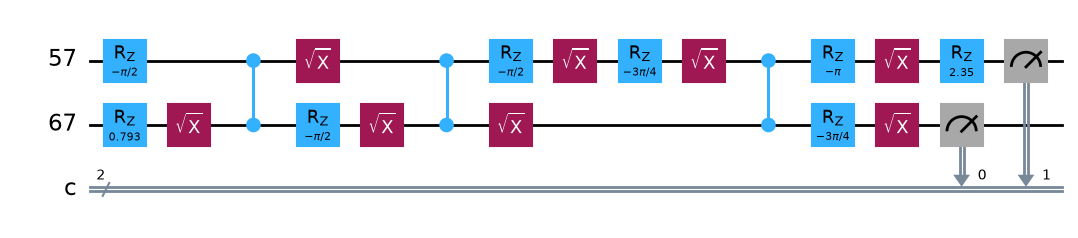

In [ ]:
circuit_to_plot = loads(compiled_circuit)
circuit_to_plot.draw('mpl')

In [ ]:
qiskit_circuit_metrics = cc.get_transpilation_metrics(circuit_to_plot, backend=backend, dt=dt)
print(qiskit_circuit_metrics)

{'depth': 15, 'num_2q_gates': 3, 'duration_us': 0.0}


### Fire Opal Compile 

In [ ]:
fo_compiled_circuit = cc.fo_compiler(
    circuits=[example_circuit],
    device_name="ibm_boston",
    credentials={"token": my_api_key},
    initial_layout=None,
    unitary_resynthesis_threshold=4e-5,
)

qiskit_runtime_service._discover_account:WARNING:2026-07-15 10:45:54,235: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-07-15 10:45:56,915: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (flex), the available account instances are: Capgemini. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 10:45:56,916: Using instance: Capgemini, plan: flex


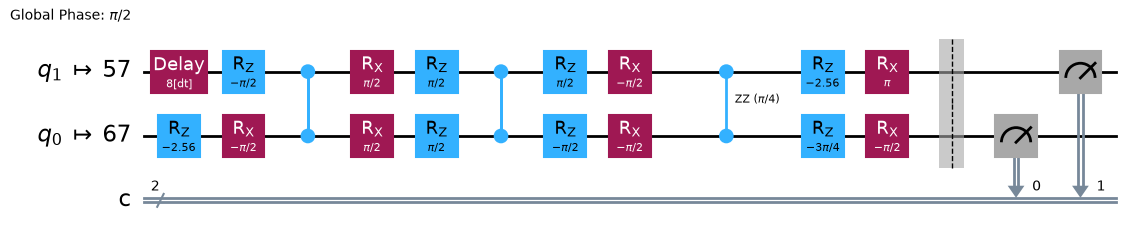

In [ ]:
# 1. Turn your string back into a Qiskit circuit object
fo_compiled_circuit = fo_compiled_circuit[0]

# 2. Plot it beautifully
fo_compiled_circuit.draw('mpl')

In [ ]:
fo_compiled_metrics = cc.get_transpilation_metrics(fo_compiled_circuit, backend=backend, dt=dt)

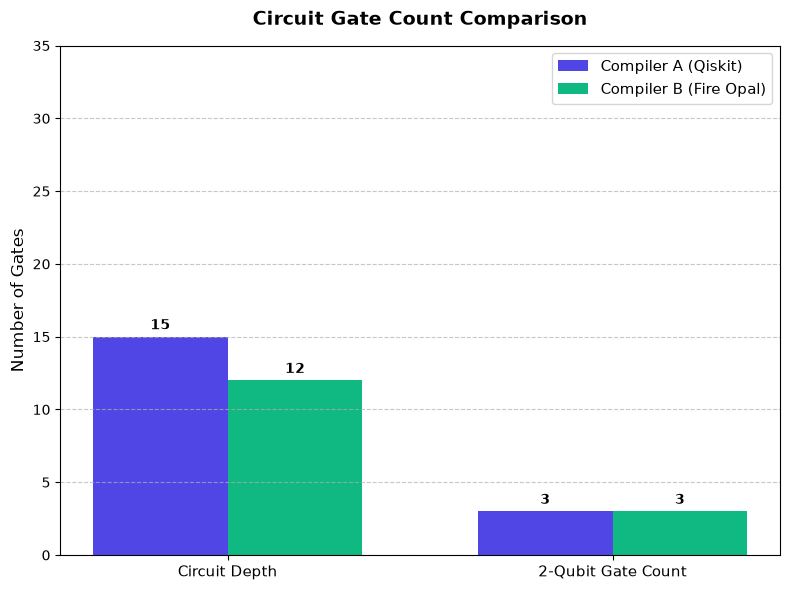

In [ ]:

# Extracting the metrics you want to plot
metrics = ['Circuit Depth', '2-Qubit Gate Count']
counts_fo = [fo_compiled_metrics['depth'], fo_compiled_metrics['num_2q_gates']]
counts_qiskit = [qiskit_circuit_metrics['depth'], qiskit_circuit_metrics['num_2q_gates']]


x = np.arange(len(metrics))  # Label locations
width = 0.35  # Width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars for both datasets side-by-side
rects1 = ax.bar(x - width/2, counts_qiskit, width, label='Compiler A (Qiskit)', color='#4F46E5')
rects2 = ax.bar(x + width/2, counts_fo, width, label='Compiler B (Fire Opal)', color='#10B981')

# Add values on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Styling and labels
ax.set_ylabel('Number of Gates', fontsize=12)
ax.set_title('Circuit Gate Count Comparison', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, max(counts_fo + counts_qiskit) + 20) # Add padding at the top
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

## Loop over Many Different Circuits to Compile

Want to extract and compile one circuit per number qubits,there are up to 58 qubits per each qft method, only even numbers so want to have 29 circuits per qft method?

In [ ]:
qft_methods = circuit_df['qft_method'].unique()
print(qft_methods)

['TwineQFTHeavyHex' 'TwineQFTLinear' 'FowlerQFT']


In [ ]:
# 20 circuits per even number means we can step by 2 up to 58
qubit_counts = list(range(2, 60, 2))

In [ ]:
# Dictionary to hold the final results for plotting
circuit_samples = {}

In [ ]:

for method in qft_methods:
    circuit_samples[method] = {}
    
    # Filter dataframe down to just this method's 580 rows
    method_df = circuit_df[circuit_df['qft_method'] == method]
    for qubits in qubit_counts:
        # Filter the method dataframe further for the specific qubit size (20 rows)
        qubit_df = method_df[method_df['number_of_qubits'] == qubits]
        
        # Check to make sure we actually have at least 10 circuits available
        if len(qubit_df) >= 10:
            # Extract the 10th circuit (index 9) raw QASM string
            raw_qasm = qubit_df.iloc[9]['transpiled_circuit']
            # Convert the QASM string to a real Qiskit QuantumCircuit object
            circuit_obj = loads(raw_qasm)

            # Store the circuit object under this qubit size
            circuit_samples[method][qubits] = circuit_obj

In [ ]:
heavyhex_10th_dict = lc.get_xth_circuits(circuit_df, 'TwineQFTHeavyHex', x=10)
fowler_10th_dict = lc.get_xth_circuits(circuit_df, 'FowlerQFT', x=10)
linear_10th_dict = lc.get_xth_circuits(circuit_df, 'TwineQFTLinear', x=10)


In [ ]:
circuit_samples = {
    'TwineQFTHeavyHex': heavyhex_10th_dict,
    'FowlerQFT': fowler_10th_dict,
    'TwineQFTLinear': linear_10th_dict
}

In [ ]:
hh_compiled_circuits = {}
for circuit in heavyhex_10th_dict.values():
    compiled_circuit = cc.qiskit_compile(circuit, backend=backend)
    hh_compiled_circuits[circuit.num_qubits] = compiled_circuit 
    print(f"Compiled circuit for {circuit.num_qubits} qubits.")


Compiled circuit for 2 qubits.
Compiled circuit for 4 qubits.
Compiled circuit for 6 qubits.
Compiled circuit for 8 qubits.
Compiled circuit for 10 qubits.
Compiled circuit for 12 qubits.
Compiled circuit for 14 qubits.
Compiled circuit for 16 qubits.
Compiled circuit for 18 qubits.
Compiled circuit for 20 qubits.
Compiled circuit for 22 qubits.
Compiled circuit for 24 qubits.
Compiled circuit for 26 qubits.
Compiled circuit for 28 qubits.
Compiled circuit for 30 qubits.
Compiled circuit for 32 qubits.
Compiled circuit for 34 qubits.
Compiled circuit for 36 qubits.
Compiled circuit for 38 qubits.
Compiled circuit for 40 qubits.
Compiled circuit for 42 qubits.
Compiled circuit for 44 qubits.
Compiled circuit for 46 qubits.
Compiled circuit for 48 qubits.
Compiled circuit for 50 qubits.
Compiled circuit for 52 qubits.
Compiled circuit for 54 qubits.
Compiled circuit for 56 qubits.
Compiled circuit for 58 qubits.


In [ ]:
for circuit in hh_compiled_circuits.values():
    compiled_circuit_obj = loads(circuit)
    metrics = lc.analyse_circuit_parameters(compiled_circuit_obj)
    print(f"Qubit Count: {compiled_circuit_obj.num_qubits}, Depth: {metrics['circuit_depth']}, 2-Qubit Gates: {metrics['two_qubit_gate_count']}")

NameError: name 'hh_compiled_circuits' is not defined